In [1]:
#import statements
import numpy as np
import rebound
import matplotlib.pyplot as plt
from celmech import Poincare, PoincareHamiltonian
from celmech.disturbing_function import laplace_b, df_coefficient_Ctilde, evaluate_df_coefficient_dict
import symengine as se
from tqdm import tqdm
import heyoka as hy
from scipy import signal
import sympy as sp
import time

from hk_integrator import hk_integrate, ft, pomega_ft, get_pomega, get_ecc

#constants
m_sat = 2.85837e-4
m_jup = 9.945786e-4
m_c = 1

## the edge of chaos using whfast (n-body)

### adjusting Jupiter eccentricity

In [56]:
sim_test_n_body = rebound.Simulation()
sim_test_n_body.add(m=1, hash = "Sun")
sim_test_n_body.add(m=m_jup,a=5.6,e=0.015,inc = 0,Omega = 0,pomega=np.radians(13.983865),hash="Jupiter")
sim_test_n_body.add(m=1e-10,a=8.87,e=0.04,inc = 0, Omega = 0,pomega=np.radians(88.719425),hash="Saturn")

sim_test_n_body.move_to_com()

sat = sim_test_n_body.particles[2]
jup = sim_test_n_body.particles[1]

times = np.linspace(0,1e6,int(1e5))*2*np.pi
long_peri_sat_test_n_body = np.zeros(len(times))
e_sat_test_n_body = np.zeros(len(times))
a_sat_test_n_body = np.zeros(len(times))
p_sat_test_n_body = np.zeros(len(times))
lam_sat = np.zeros(len(times))

long_peri_j_test_n_body = np.zeros(len(times))
e_j_test_n_body = np.zeros(len(times))
a_j_test_n_body = np.zeros(len(times))
p_j_test_n_body = np.zeros(len(times))
lam_jup = np.zeros(len(times))

sim_test_n_body.init_megno()
e_i = sim_test_n_body.energy()

for i in tqdm(range(len(times))):
    sim_test_n_body.integrate(times[i])
    
    long_peri_sat_test_n_body[i] = sat.pomega
    e_sat_test_n_body[i] = sat.e
    a_sat_test_n_body[i] = sat.a
    p_sat_test_n_body[i] = sat.P
    lam_sat[i] = sat.l

    long_peri_j_test_n_body[i] = jup.pomega
    e_j_test_n_body[i] = jup.e
    a_j_test_n_body[i] = jup.a
    p_j_test_n_body[i] = jup.P
    lam_jup[i] = jup.l
    
e_f = sim_test_n_body.energy()
m_f = sim_test_n_body.megno()

e_per = (np.abs(e_i - e_f)/np.abs(e_i))*100

print(f'Energy percent change: {e_per: .2e} %')
print(f'Final MEGNO value: {m_f: .2e}')

100%|█████████████████████████████████████████████████████████████████████████| 100000/100000 [00:48<00:00, 2047.48it/s]

Energy percent change:  1.01e-12 %
Final MEGNO value:  2.00e+00


In [3]:
sim_test_n_body = rebound.Simulation()
sim_test_n_body.add(m=1, hash = "Sun")
sim_test_n_body.add(m=m_jup,a=5.6,e=0.02,inc = 0,Omega = 0,pomega=np.radians(13.983865),hash="Jupiter")
sim_test_n_body.add(m=1e-10,a=8.87,e=0.04,inc = 0, Omega = 0,pomega=np.radians(88.719425),hash="Saturn")

sim_test_n_body.move_to_com()

sat = sim_test_n_body.particles[2]
jup = sim_test_n_body.particles[1]

times = np.linspace(0,1e6,int(1e5))*2*np.pi
long_peri_sat_test_n_body = np.zeros(len(times))
e_sat_test_n_body = np.zeros(len(times))
a_sat_test_n_body = np.zeros(len(times))
p_sat_test_n_body = np.zeros(len(times))
lam_sat = np.zeros(len(times))

long_peri_j_test_n_body = np.zeros(len(times))
e_j_test_n_body = np.zeros(len(times))
a_j_test_n_body = np.zeros(len(times))
p_j_test_n_body = np.zeros(len(times))
lam_jup = np.zeros(len(times))

sim_test_n_body.init_megno()
e_i = sim_test_n_body.energy()

for i in tqdm(range(len(times))):
    sim_test_n_body.integrate(times[i])
    
    long_peri_sat_test_n_body[i] = sat.pomega
    e_sat_test_n_body[i] = sat.e
    a_sat_test_n_body[i] = sat.a
    p_sat_test_n_body[i] = sat.P
    lam_sat[i] = sat.l

    long_peri_j_test_n_body[i] = jup.pomega
    e_j_test_n_body[i] = jup.e
    a_j_test_n_body[i] = jup.a
    p_j_test_n_body[i] = jup.P
    lam_jup[i] = jup.l
    
e_f = sim_test_n_body.energy()
m_f = sim_test_n_body.megno()

e_per = (np.abs(e_i - e_f)/np.abs(e_i))*100

print(f'Energy percent change: {e_per: .2e} %')
print(f'Final MEGNO value: {m_f: .2e}')

100%|█████████████████████████████████████████████████████████████████████████| 100000/100000 [00:44<00:00, 2271.93it/s]

Energy percent change:  6.41e-13 %
Final MEGNO value:  1.05e+02


### adjusting Saturn Eccentricity

In [8]:
sim_test_n_body = rebound.Simulation()
sim_test_n_body.add(m=1, hash = "Sun")
sim_test_n_body.add(m=m_jup,a=5.6,e=0.06,inc = 0,Omega = 0,pomega=np.radians(13.983865),hash="Jupiter")
sim_test_n_body.add(m=1e-10,a=8.87,e=0.0,inc = 0, Omega = 0,pomega=np.radians(88.719425),hash="Saturn")

sim_test_n_body.move_to_com()

sat = sim_test_n_body.particles[2]
jup = sim_test_n_body.particles[1]

times = np.linspace(0,1e6,int(1e5))*2*np.pi
long_peri_sat_test_n_body = np.zeros(len(times))
e_sat_test_n_body = np.zeros(len(times))
a_sat_test_n_body = np.zeros(len(times))
p_sat_test_n_body = np.zeros(len(times))
lam_sat = np.zeros(len(times))

long_peri_j_test_n_body = np.zeros(len(times))
e_j_test_n_body = np.zeros(len(times))
a_j_test_n_body = np.zeros(len(times))
p_j_test_n_body = np.zeros(len(times))
lam_jup = np.zeros(len(times))

sim_test_n_body.init_megno()
e_i = sim_test_n_body.energy()

for i in tqdm(range(len(times))):
    sim_test_n_body.integrate(times[i])
    
    long_peri_sat_test_n_body[i] = sat.pomega
    e_sat_test_n_body[i] = sat.e
    a_sat_test_n_body[i] = sat.a
    p_sat_test_n_body[i] = sat.P
    lam_sat[i] = sat.l

    long_peri_j_test_n_body[i] = jup.pomega
    e_j_test_n_body[i] = jup.e
    a_j_test_n_body[i] = jup.a
    p_j_test_n_body[i] = jup.P
    lam_jup[i] = jup.l
    
e_f = sim_test_n_body.energy()
m_f = sim_test_n_body.megno()

e_per = (np.abs(e_i - e_f)/np.abs(e_i))*100

print(f'Energy percent change: {e_per: .2e} %')
print(f'Final MEGNO value: {m_f: .2f}')

100%|█████████████████████████████████████████████████████████████████████████| 100000/100000 [00:49<00:00, 2015.61it/s]

Energy percent change:  9.46e-13 %
Final MEGNO value:  18.50


In [10]:
sim_test_n_body = rebound.Simulation()
sim_test_n_body.add(m=1, hash = "Sun")
sim_test_n_body.add(m=m_jup,a=5.6,e=0.06,inc = 0,Omega = 0,pomega=np.radians(13.983865),hash="Jupiter")
sim_test_n_body.add(m=1e-10,a=8.87,e=0.01,inc = 0, Omega = 0,pomega=np.radians(88.719425),hash="Saturn")

sim_test_n_body.move_to_com()

sat = sim_test_n_body.particles[2]
jup = sim_test_n_body.particles[1]

times = np.linspace(0,1e6,int(1e5))*2*np.pi
long_peri_sat_test_n_body = np.zeros(len(times))
e_sat_test_n_body = np.zeros(len(times))
a_sat_test_n_body = np.zeros(len(times))
p_sat_test_n_body = np.zeros(len(times))
lam_sat = np.zeros(len(times))

long_peri_j_test_n_body = np.zeros(len(times))
e_j_test_n_body = np.zeros(len(times))
a_j_test_n_body = np.zeros(len(times))
p_j_test_n_body = np.zeros(len(times))
lam_jup = np.zeros(len(times))

sim_test_n_body.init_megno()
e_i = sim_test_n_body.energy()

for i in tqdm(range(len(times))):
    sim_test_n_body.integrate(times[i])
    
    long_peri_sat_test_n_body[i] = sat.pomega
    e_sat_test_n_body[i] = sat.e
    a_sat_test_n_body[i] = sat.a
    p_sat_test_n_body[i] = sat.P
    lam_sat[i] = sat.l

    long_peri_j_test_n_body[i] = jup.pomega
    e_j_test_n_body[i] = jup.e
    a_j_test_n_body[i] = jup.a
    p_j_test_n_body[i] = jup.P
    lam_jup[i] = jup.l
    
e_f = sim_test_n_body.energy()
m_f = sim_test_n_body.megno()

e_per = (np.abs(e_i - e_f)/np.abs(e_i))*100

print(f'Energy percent change: {e_per: .2e} %')
print(f'Final MEGNO value: {m_f: .2f}')

100%|█████████████████████████████████████████████████████████████████████████| 100000/100000 [00:46<00:00, 2152.59it/s]

Energy percent change:  2.41e-12 %
Final MEGNO value:  180.85


## looking at the fts of phi (whfast n-body)

In [61]:
#jupiter low eccentricity no chaos

sim_test_n_body = rebound.Simulation()
sim_test_n_body.add(m=1, hash = "Sun")
sim_test_n_body.add(m=m_jup,a=5.6,e=0.015,inc = 0,Omega = 0,pomega=np.radians(13.983865),hash="Jupiter")
sim_test_n_body.add(m=1e-10,a=8.87,e=0.04,inc = 0, Omega = 0,pomega=np.radians(88.719425),hash="Saturn")

sim_test_n_body.move_to_com()

sat = sim_test_n_body.particles[2]
jup = sim_test_n_body.particles[1]

times = np.linspace(0,1e6,int(1e5))*2*np.pi
long_peri_sat_test_n_body = np.zeros(len(times))
e_sat_test_n_body = np.zeros(len(times))
a_sat_test_n_body = np.zeros(len(times))
p_sat_test_n_body = np.zeros(len(times))
lam_sat = np.zeros(len(times))

long_peri_j_test_n_body = np.zeros(len(times))
e_j_test_n_body = np.zeros(len(times))
a_j_test_n_body = np.zeros(len(times))
p_j_test_n_body = np.zeros(len(times))
lam_jup = np.zeros(len(times))

sim_test_n_body.init_megno()
e_i = sim_test_n_body.energy()

for i in tqdm(range(len(times))):
    sim_test_n_body.integrate(times[i])
    
    long_peri_sat_test_n_body[i] = sat.pomega
    e_sat_test_n_body[i] = sat.e
    a_sat_test_n_body[i] = sat.a
    p_sat_test_n_body[i] = sat.P
    lam_sat[i] = sat.l

    long_peri_j_test_n_body[i] = jup.pomega
    e_j_test_n_body[i] = jup.e
    a_j_test_n_body[i] = jup.a
    p_j_test_n_body[i] = jup.P
    lam_jup[i] = jup.l
    
e_f = sim_test_n_body.energy()
m_f = sim_test_n_body.megno()

e_per = (np.abs(e_i - e_f)/np.abs(e_i))*100

print(f'Energy percent change: {e_per: .2e} %')
print(f'Final MEGNO value: {m_f: .2e}')

100%|█████████████████████████████████████████████████████████████████████████| 100000/100000 [00:47<00:00, 2093.67it/s]

Energy percent change:  3.20e-13 %
Final MEGNO value:  2.00e+00


In [14]:
phi_2_mixed = 4*lam_sat - 2*lam_jup - long_peri_sat_test_n_body - long_peri_j_test_n_body

phi_3_mixed_s = 6*lam_sat - 3*lam_jup - 2*long_peri_sat_test_n_body - long_peri_j_test_n_body
phi_3_mixed_j = 6*lam_sat - 3*lam_jup - long_peri_sat_test_n_body - 2*long_peri_j_test_n_body

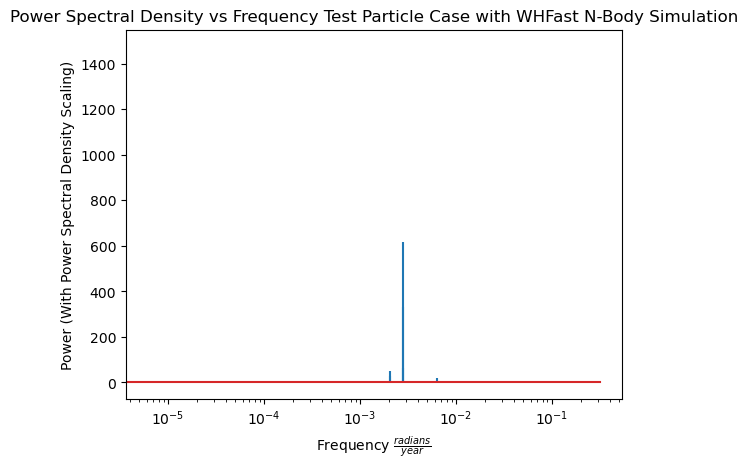

In [15]:
f,pxx = pomega_ft(times, long_peri_sat_test_n_body, e_sat_test_n_body)
plt.stem(f*2*np.pi,pxx,markerfmt = "none",label = 'Frequencies found through simulation')
plt.xscale('log')
plt.ylabel('Power (With Power Spectral Density Scaling)')
plt.xlabel(r"Frequency $\frac{radians}{year}$")
plt.title(r'Power Spectral Density vs Frequency Test Particle Case with WHFast N-Body Simulation')
plt.show()

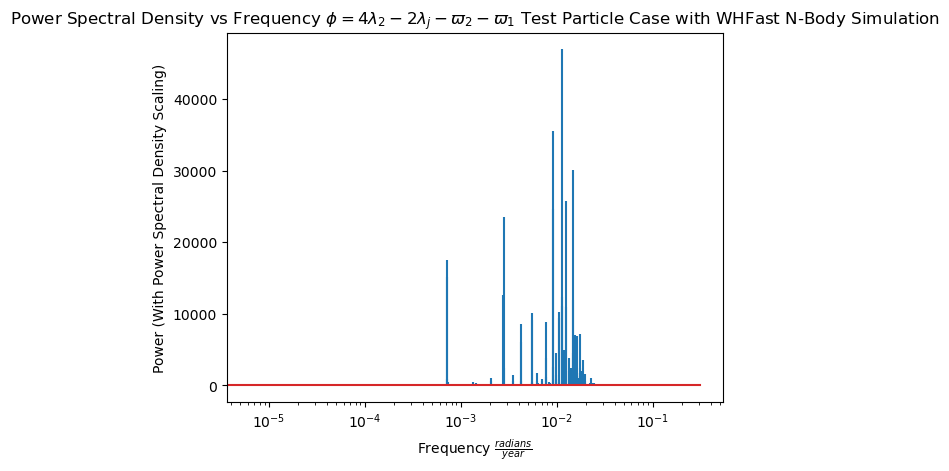

In [16]:
f,pxx = ft(times, np.cos(phi_2_mixed))
plt.stem(f*2*np.pi,pxx,markerfmt = "none",label = 'Frequencies found through simulation')
plt.xscale('log')
plt.ylabel('Power (With Power Spectral Density Scaling)')
plt.xlabel(r"Frequency $\frac{radians}{year}$")
plt.title(r'Power Spectral Density vs Frequency $\phi = 4\lambda_2 -2\lambda_j - \varpi_2 - \varpi_1$ Test Particle Case with WHFast N-Body Simulation')
plt.show()

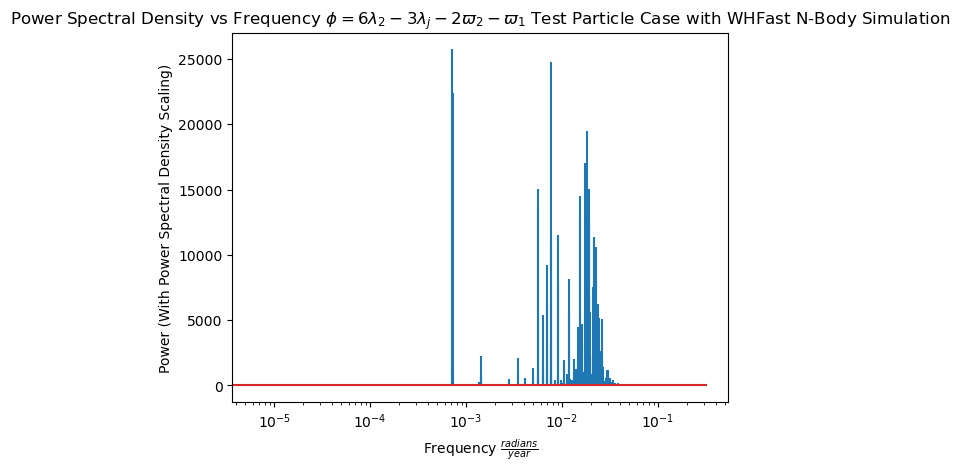

In [17]:
f,pxx = ft(times, np.cos(phi_3_mixed_s))
plt.stem(f*2*np.pi,pxx,markerfmt = "none",label = 'Frequencies found through simulation')
plt.xscale('log')
plt.ylabel('Power (With Power Spectral Density Scaling)')
plt.xlabel(r"Frequency $\frac{radians}{year}$")
plt.title(r'Power Spectral Density vs Frequency $\phi = 6\lambda_2 -3\lambda_j - 2\varpi_2 - \varpi_1$ Test Particle Case with WHFast N-Body Simulation')
plt.show()

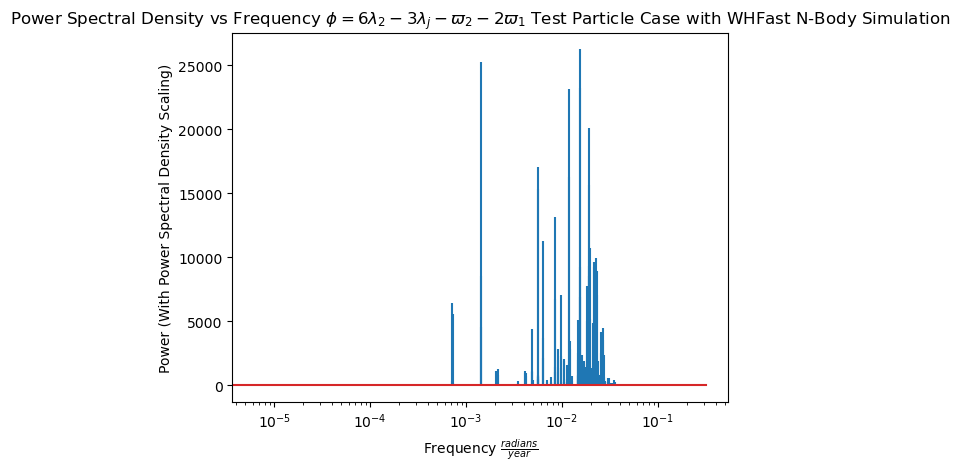

In [18]:
f,pxx = ft(times, np.cos(phi_3_mixed_j))
plt.stem(f*2*np.pi,pxx,markerfmt = "none",label = 'Frequencies found through simulation')
plt.xscale('log')
plt.ylabel('Power (With Power Spectral Density Scaling)')
plt.xlabel(r"Frequency $\frac{radians}{year}$")
plt.title(r'Power Spectral Density vs Frequency $\phi = 6\lambda_2 -3\lambda_j - \varpi_2 - 2\varpi_1$ Test Particle Case with WHFast N-Body Simulation')
plt.show()

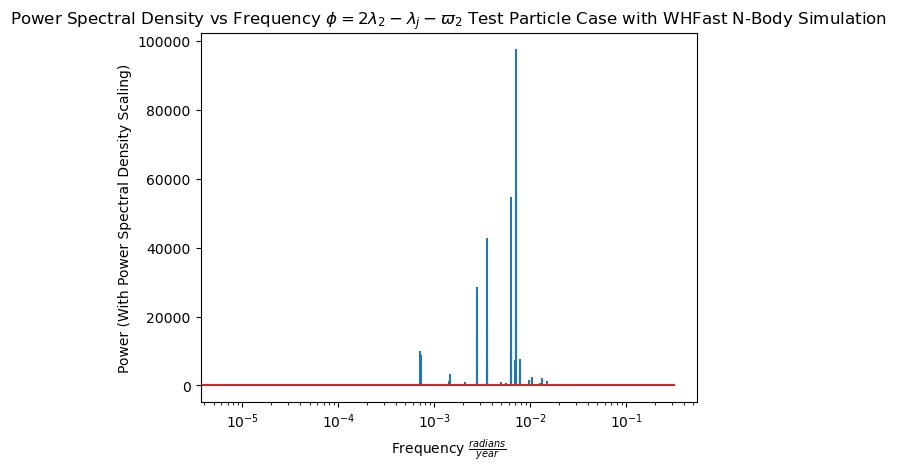

In [62]:
phi_1_s = 2*lam_sat - lam_jup - long_peri_sat_test_n_body

f,pxx = ft(times, np.cos(phi_1_s))
plt.stem(f*2*np.pi,pxx,markerfmt = "none",label = 'Frequencies found through simulation')
plt.xscale('log')
plt.ylabel('Power (With Power Spectral Density Scaling)')
plt.xlabel(r"Frequency $\frac{radians}{year}$")
plt.title(r'Power Spectral Density vs Frequency $\phi = 2\lambda_2 -\lambda_j - \varpi_2$ Test Particle Case with WHFast N-Body Simulation')
plt.show()

In [58]:
#jupiter eccentricity high enough for chaos

sim_test_n_body = rebound.Simulation()
sim_test_n_body.add(m=1, hash = "Sun")
sim_test_n_body.add(m=m_jup,a=5.6,e=0.02,inc = 0,Omega = 0,pomega=np.radians(13.983865),hash="Jupiter")
sim_test_n_body.add(m=1e-10,a=8.87,e=0.04,inc = 0, Omega = 0,pomega=np.radians(88.719425),hash="Saturn")

sim_test_n_body.move_to_com()

sat = sim_test_n_body.particles[2]
jup = sim_test_n_body.particles[1]

times = np.linspace(0,1e6,int(1e5))*2*np.pi
long_peri_sat_test_n_body = np.zeros(len(times))
e_sat_test_n_body = np.zeros(len(times))
a_sat_test_n_body = np.zeros(len(times))
p_sat_test_n_body = np.zeros(len(times))
lam_sat = np.zeros(len(times))

long_peri_j_test_n_body = np.zeros(len(times))
e_j_test_n_body = np.zeros(len(times))
a_j_test_n_body = np.zeros(len(times))
p_j_test_n_body = np.zeros(len(times))
lam_jup = np.zeros(len(times))

sim_test_n_body.init_megno()
e_i = sim_test_n_body.energy()

for i in tqdm(range(len(times))):
    sim_test_n_body.integrate(times[i])
    
    long_peri_sat_test_n_body[i] = sat.pomega
    e_sat_test_n_body[i] = sat.e
    a_sat_test_n_body[i] = sat.a
    p_sat_test_n_body[i] = sat.P
    lam_sat[i] = sat.l

    long_peri_j_test_n_body[i] = jup.pomega
    e_j_test_n_body[i] = jup.e
    a_j_test_n_body[i] = jup.a
    p_j_test_n_body[i] = jup.P
    lam_jup[i] = jup.l
    
e_f = sim_test_n_body.energy()
m_f = sim_test_n_body.megno()

e_per = (np.abs(e_i - e_f)/np.abs(e_i))*100

print(f'Energy percent change: {e_per: .2e} %')
print(f'Final MEGNO value: {m_f: .2e}')

100%|█████████████████████████████████████████████████████████████████████████| 100000/100000 [00:44<00:00, 2235.53it/s]

Energy percent change:  2.00e-12 %
Final MEGNO value:  1.11e+02


In [20]:
phi_2_mixed = 4*lam_sat - 2*lam_jup - long_peri_sat_test_n_body - long_peri_j_test_n_body

phi_3_mixed_s = 6*lam_sat - 3*lam_jup - 2*long_peri_sat_test_n_body - long_peri_j_test_n_body
phi_3_mixed_j = 6*lam_sat - 3*lam_jup - long_peri_sat_test_n_body - 2*long_peri_j_test_n_body

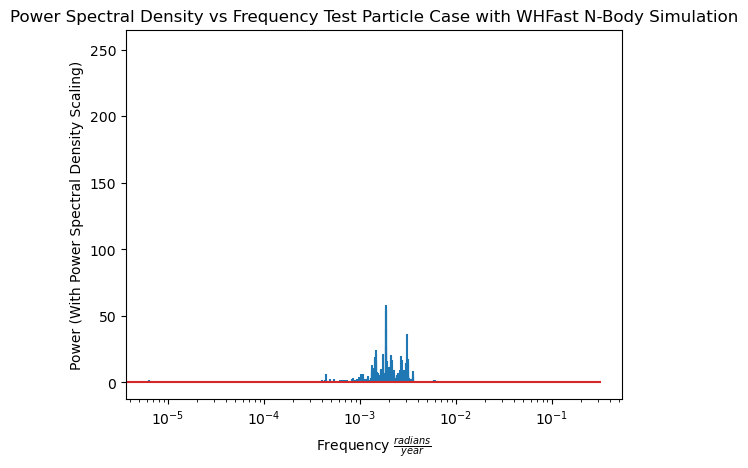

In [21]:
f,pxx = pomega_ft(times, long_peri_sat_test_n_body, e_sat_test_n_body)
plt.stem(f*2*np.pi,pxx,markerfmt = "none",label = 'Frequencies found through simulation')
plt.xscale('log')
plt.ylabel('Power (With Power Spectral Density Scaling)')
plt.xlabel(r"Frequency $\frac{radians}{year}$")
plt.title(r'Power Spectral Density vs Frequency Test Particle Case with WHFast N-Body Simulation')
plt.show()

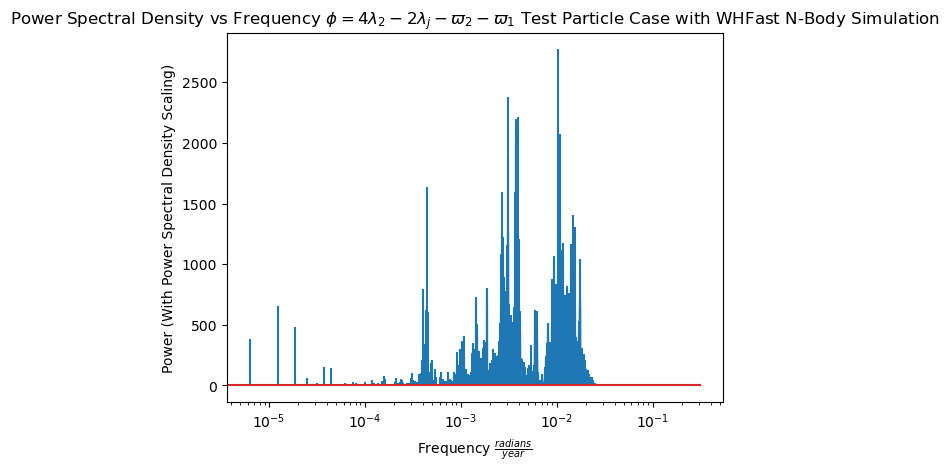

In [22]:
f,pxx = ft(times, np.cos(phi_2_mixed))
plt.stem(f*2*np.pi,pxx,markerfmt = "none",label = 'Frequencies found through simulation')
plt.xscale('log')
plt.ylabel('Power (With Power Spectral Density Scaling)')
plt.xlabel(r"Frequency $\frac{radians}{year}$")
plt.title(r'Power Spectral Density vs Frequency $\phi = 4\lambda_2 -2\lambda_j - \varpi_2 - \varpi_1$ Test Particle Case with WHFast N-Body Simulation')
plt.show()

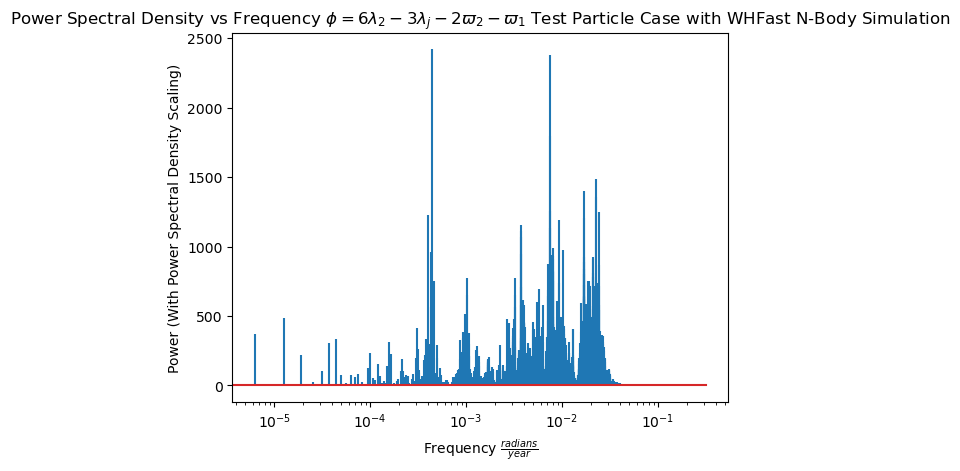

In [23]:
f,pxx = ft(times, np.cos(phi_3_mixed_s))
plt.stem(f*2*np.pi,pxx,markerfmt = "none",label = 'Frequencies found through simulation')
plt.xscale('log')
plt.ylabel('Power (With Power Spectral Density Scaling)')
plt.xlabel(r"Frequency $\frac{radians}{year}$")
plt.title(r'Power Spectral Density vs Frequency $\phi = 6\lambda_2 -3\lambda_j - 2\varpi_2 - \varpi_1$ Test Particle Case with WHFast N-Body Simulation')
plt.show()

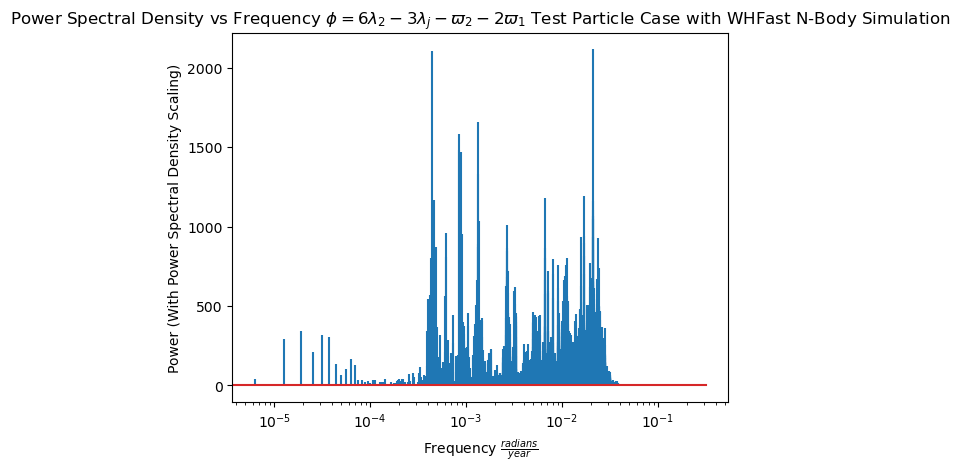

In [24]:
f,pxx = ft(times, np.cos(phi_3_mixed_j))
plt.stem(f*2*np.pi,pxx,markerfmt = "none",label = 'Frequencies found through simulation')
plt.xscale('log')
plt.ylabel('Power (With Power Spectral Density Scaling)')
plt.xlabel(r"Frequency $\frac{radians}{year}$")
plt.title(r'Power Spectral Density vs Frequency $\phi = 6\lambda_2 -3\lambda_j - \varpi_2 - 2\varpi_1$ Test Particle Case with WHFast N-Body Simulation')
plt.show()

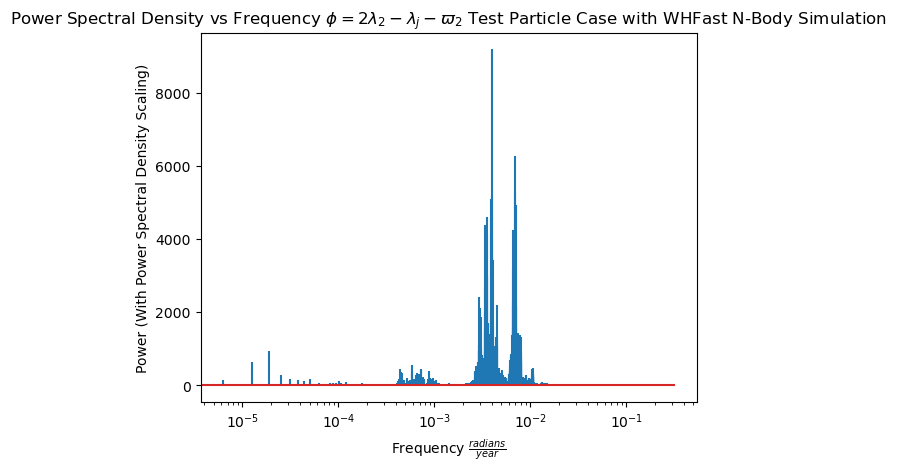

In [60]:
phi_1_s = 2*lam_sat - lam_jup - long_peri_sat_test_n_body

f,pxx = ft(times, np.cos(phi_1_s))
plt.stem(f*2*np.pi,pxx,markerfmt = "none",label = 'Frequencies found through simulation')
plt.xscale('log')
plt.ylabel('Power (With Power Spectral Density Scaling)')
plt.xlabel(r"Frequency $\frac{radians}{year}$")
plt.title(r'Power Spectral Density vs Frequency $\phi = 2\lambda_2 -\lambda_j - \varpi_2$ Test Particle Case with WHFast N-Body Simulation')
plt.show()

## looking at the phis (with celmech)

### looking only at second order

In [82]:
#low jup eccentricity

sim = rebound.Simulation()
sim.add(m=1, hash = "Sun")
sim.add(m=m_jup,a=5.6,e=0.015,inc = 0,Omega = 0,pomega=np.radians(13.983865),hash="Jupiter")
sim.add(m=1e-10,a=8.87,e=0.04,inc = 0, Omega = 0,pomega=np.radians(88.719425),hash="Saturn")

pvars = Poincare.from_Simulation(sim)

pham = PoincareHamiltonian(pvars)
pham.add_MMR_terms(2,1,indexIn = 1, indexOut = 2, max_order = 2)
pham.add_secular_terms(indexIn = 1, indexOut = 2, max_order = 2)

times, pomega_sat, pomega_j, e_sat, a_sat, a_jup, lam_sat,lam_jup = hk_integrate(pham, 1e6, 1e5)

['Lambda1', 'Lambda2', 'eta1', 'eta2', 'kappa1', 'kappa2', 'lambda1', 'lambda2']
*** Differentiating  ***
-8.880166634732841e-05
*** Starting Simulation ***


100%|████████████████████████████████████████████████████████████████████████| 100000/100000 [00:06<00:00, 16083.57it/s]

-8.880166634733718e-05
Energy Percent Change: 9.874234832126342e-12 %
*** Simulation Complete ***
Time elapsed  = 6.2202134600001955 seconds


In [83]:
phi_2_mixed = 4*lam_sat - 2*lam_jup - pomega_sat - long_peri_j_test_n_body

phi_3_mixed_s = 6*lam_sat - 3*lam_jup - 2*pomega_sat - pomega_j
phi_3_mixed_j = 6*lam_sat - 3*lam_jup - pomega_sat - 2*pomega_j

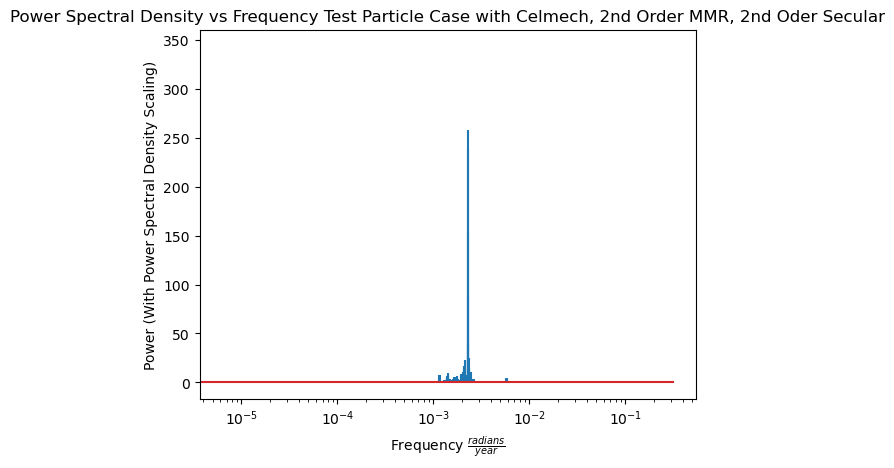

In [84]:
f,pxx = pomega_ft(times, pomega_sat, e_sat)
plt.stem(f*2*np.pi,pxx,markerfmt = "none",label = 'Frequencies found through simulation')
plt.xscale('log')
plt.ylabel('Power (With Power Spectral Density Scaling)')
plt.xlabel(r"Frequency $\frac{radians}{year}$")
plt.title(r'Power Spectral Density vs Frequency Test Particle Case with Celmech, 2nd Order MMR, 2nd Oder Secular')
plt.show()

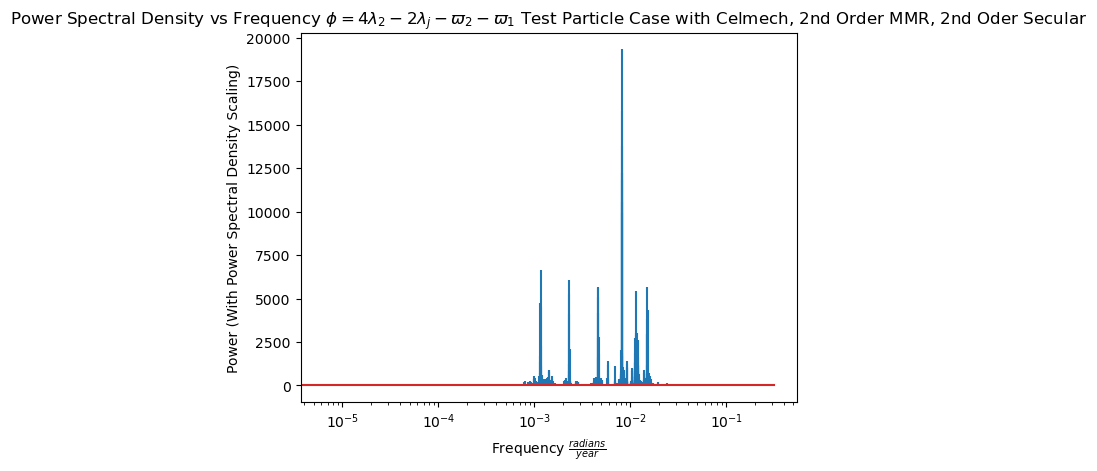

In [85]:
f,pxx = ft(times, np.cos(phi_2_mixed))
plt.stem(f*2*np.pi,pxx,markerfmt = "none",label = 'Frequencies found through simulation')
plt.xscale('log')
plt.ylabel('Power (With Power Spectral Density Scaling)')
plt.xlabel(r"Frequency $\frac{radians}{year}$")
plt.title(r'Power Spectral Density vs Frequency $\phi = 4\lambda_2 -2\lambda_j - \varpi_2 - \varpi_1$ Test Particle Case with Celmech, 2nd Order MMR, 2nd Oder Secular')
plt.show()

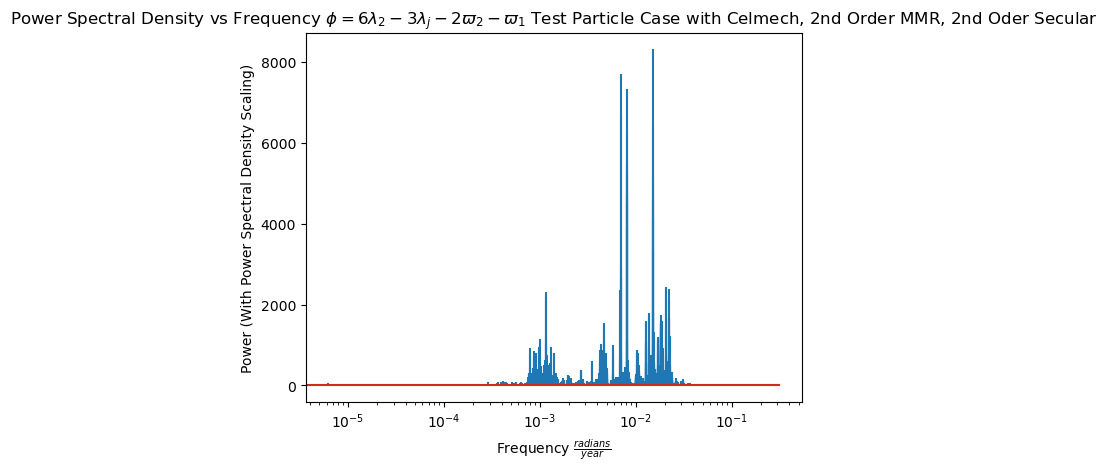

In [86]:
f,pxx = ft(times, np.cos(phi_3_mixed_s))
plt.stem(f*2*np.pi,pxx,markerfmt = "none",label = 'Frequencies found through simulation')
plt.xscale('log')
plt.ylabel('Power (With Power Spectral Density Scaling)')
plt.xlabel(r"Frequency $\frac{radians}{year}$")
plt.title(r'Power Spectral Density vs Frequency $\phi = 6\lambda_2 -3\lambda_j - 2\varpi_2 - \varpi_1$ Test Particle Case with Celmech, 2nd Order MMR, 2nd Oder Secular')
plt.show()

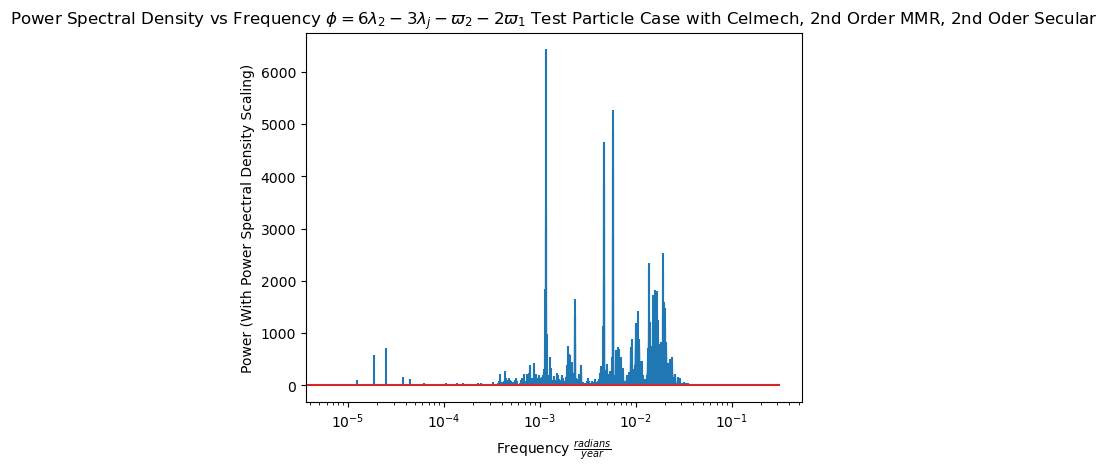

In [87]:
f,pxx = ft(times, np.cos(phi_3_mixed_j))
plt.stem(f*2*np.pi,pxx,markerfmt = "none",label = 'Frequencies found through simulation')
plt.xscale('log')
plt.ylabel('Power (With Power Spectral Density Scaling)')
plt.xlabel(r"Frequency $\frac{radians}{year}$")
plt.title(r'Power Spectral Density vs Frequency $\phi = 6\lambda_2 -3\lambda_j - \varpi_2 - 2\varpi_1$ Test Particle Case with Celmech, 2nd Order MMR, 2nd Oder Secular')
plt.show()

In [88]:
#higher jup eccentricity

sim = rebound.Simulation()
sim.add(m=1, hash = "Sun")
sim.add(m=m_jup,a=5.6,e=0.02,inc = 0,Omega = 0,pomega=np.radians(13.983865),hash="Jupiter")
sim.add(m=1e-10,a=8.87,e=0.04,inc = 0, Omega = 0,pomega=np.radians(88.719425),hash="Saturn")

pvars = Poincare.from_Simulation(sim)

pham = PoincareHamiltonian(pvars)
pham.add_MMR_terms(2,1,indexIn = 1, indexOut = 2, max_order = 2)
pham.add_secular_terms(indexIn = 1, indexOut = 2, max_order = 2)

times, pomega_sat, pomega_j, e_sat, a_sat, a_jup, lam_sat,lam_jup = hk_integrate(pham, 1e6, 1e5)

['Lambda1', 'Lambda2', 'eta1', 'eta2', 'kappa1', 'kappa2', 'lambda1', 'lambda2']
*** Differentiating  ***
-8.880166634742618e-05
*** Starting Simulation ***


100%|████████████████████████████████████████████████████████████████████████| 100000/100000 [00:06<00:00, 15322.84it/s]

-8.880166634741786e-05
Energy Percent Change: 9.370603070972022e-12 %
*** Simulation Complete ***
Time elapsed  = 6.529431890000524 seconds


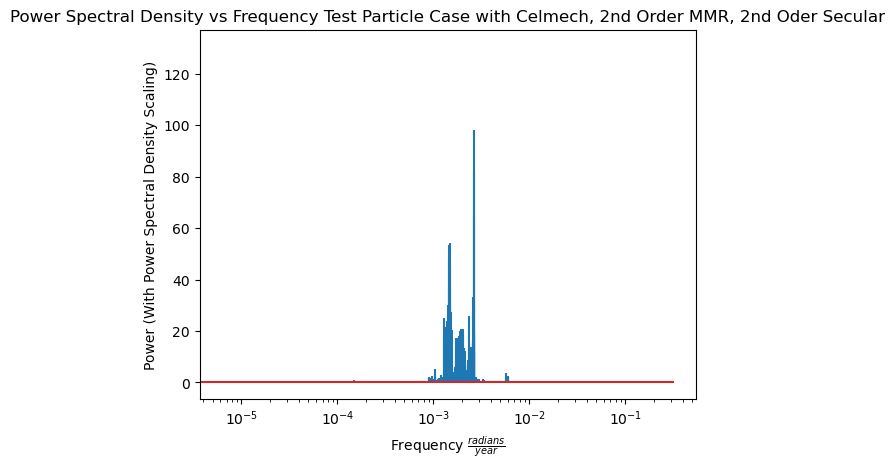

In [78]:
phi_2_mixed = 4*lam_sat - 2*lam_jup - pomega_sat - long_peri_j_test_n_body

phi_3_mixed_s = 6*lam_sat - 3*lam_jup - 2*pomega_sat - pomega_j
phi_3_mixed_j = 6*lam_sat - 3*lam_jup - pomega_sat - 2*pomega_j

f,pxx = pomega_ft(times, pomega_sat, e_sat)
plt.stem(f*2*np.pi,pxx,markerfmt = "none",label = 'Frequencies found through simulation')
plt.xscale('log')
plt.ylabel('Power (With Power Spectral Density Scaling)')
plt.xlabel(r"Frequency $\frac{radians}{year}$")
plt.title(r'Power Spectral Density vs Frequency Test Particle Case with Celmech, 2nd Order MMR, 2nd Oder Secular')
plt.show()

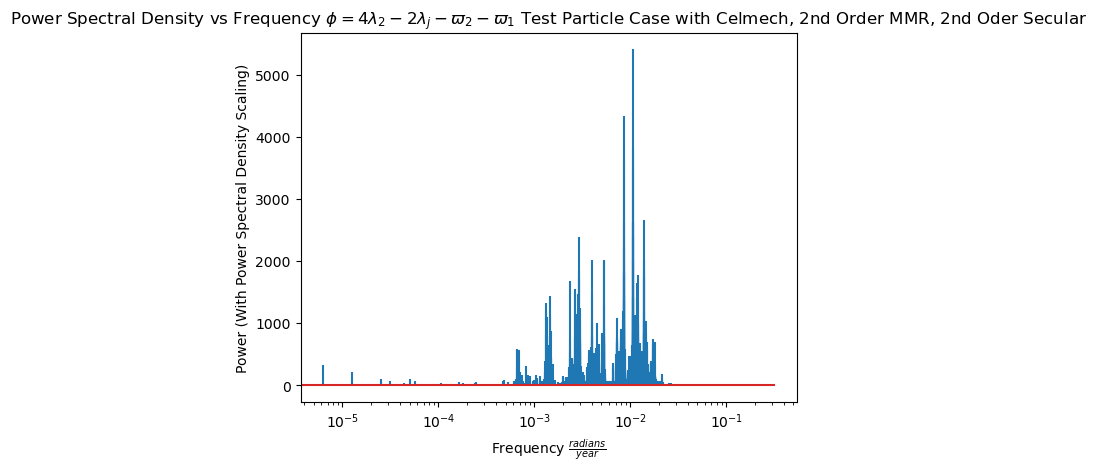

In [80]:
f,pxx = ft(times, np.cos(phi_2_mixed))
plt.stem(f*2*np.pi,pxx,markerfmt = "none",label = 'Frequencies found through simulation')
plt.xscale('log')
plt.ylabel('Power (With Power Spectral Density Scaling)')
plt.xlabel(r"Frequency $\frac{radians}{year}$")
plt.title(r'Power Spectral Density vs Frequency $\phi = 4\lambda_2 -2\lambda_j - \varpi_2 - \varpi_1$ Test Particle Case with Celmech, 2nd Order MMR, 2nd Oder Secular')
plt.show()

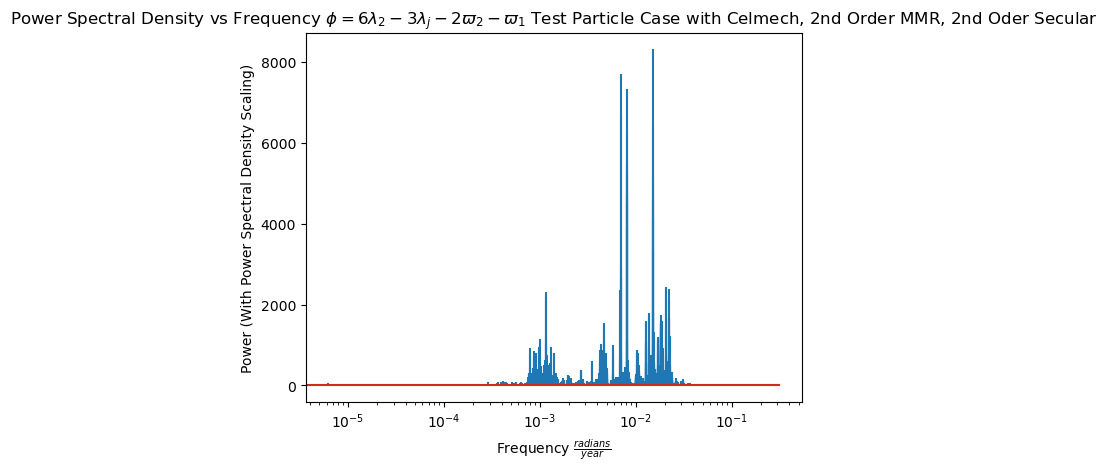

In [89]:
f,pxx = ft(times, np.cos(phi_3_mixed_s))
plt.stem(f*2*np.pi,pxx,markerfmt = "none",label = 'Frequencies found through simulation')
plt.xscale('log')
plt.ylabel('Power (With Power Spectral Density Scaling)')
plt.xlabel(r"Frequency $\frac{radians}{year}$")
plt.title(r'Power Spectral Density vs Frequency $\phi = 6\lambda_2 -3\lambda_j - 2\varpi_2 - \varpi_1$ Test Particle Case with Celmech, 2nd Order MMR, 2nd Oder Secular')
plt.show()

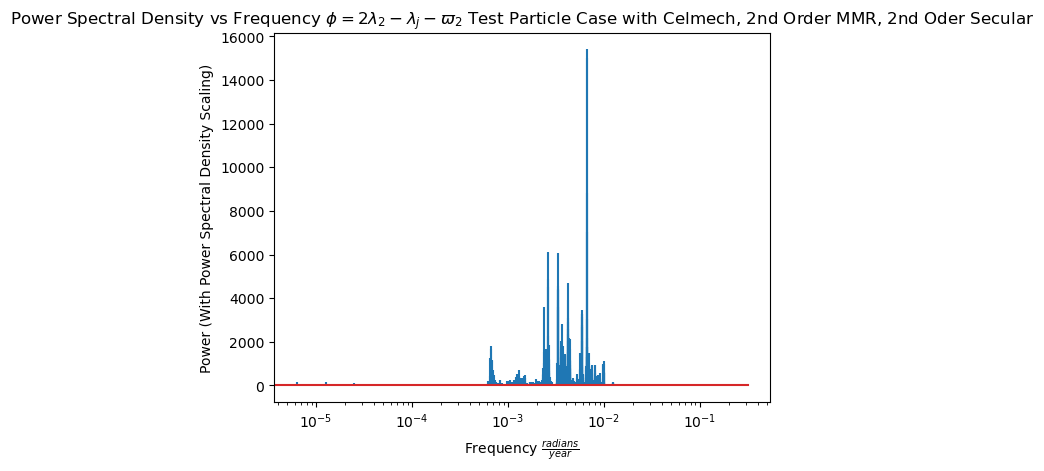

In [81]:
phi_1_s = 2*lam_sat - lam_jup - pomega_sat

f,pxx = ft(times, np.cos(phi_1_s))
plt.stem(f*2*np.pi,pxx,markerfmt = "none",label = 'Frequencies found through simulation')
plt.xscale('log')
plt.ylabel('Power (With Power Spectral Density Scaling)')
plt.xlabel(r"Frequency $\frac{radians}{year}$")
plt.title(r'Power Spectral Density vs Frequency $\phi = 2\lambda_2 -\lambda_j - \varpi_2$ Test Particle Case with Celmech, 2nd Order MMR, 2nd Oder Secular')
plt.show()

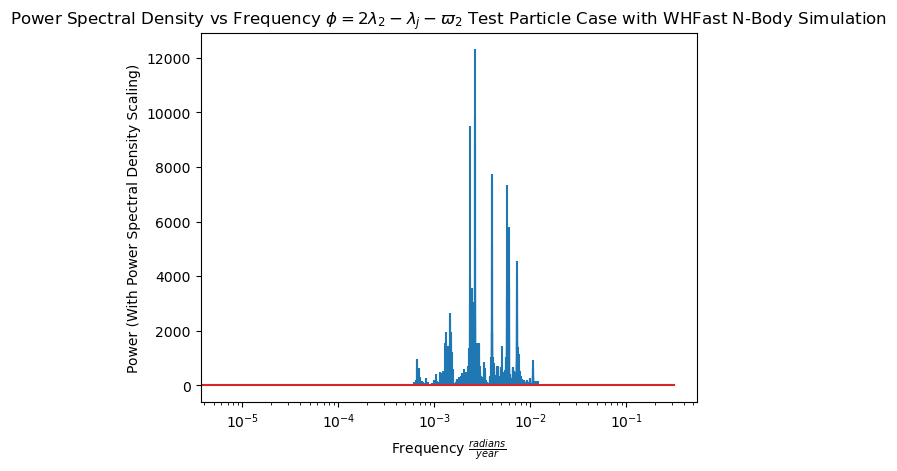

In [55]:
phi_1_j = 2*lam_sat - lam_jup - pomega_j

f,pxx = ft(times, np.cos(phi_1_j))
plt.stem(f*2*np.pi,pxx,markerfmt = "none",label = 'Frequencies found through simulation')
plt.xscale('log')
plt.ylabel('Power (With Power Spectral Density Scaling)')
plt.xlabel(r"Frequency $\frac{radians}{year}$")
plt.title(r'Power Spectral Density vs Frequency $\phi = 2\lambda_2 -\lambda_j - \varpi_2$ Test Particle Case with Celmech')
plt.show()

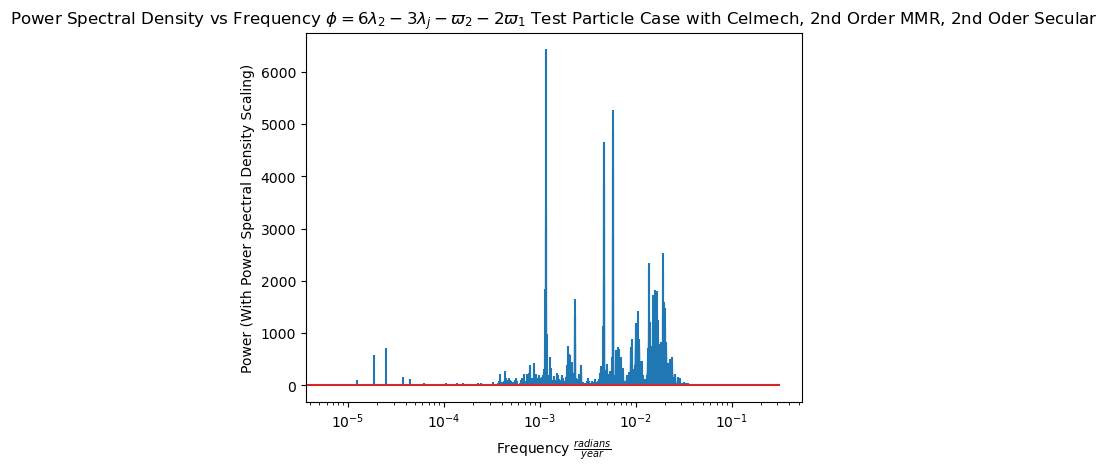

In [90]:
f,pxx = ft(times, np.cos(phi_3_mixed_j))
plt.stem(f*2*np.pi,pxx,markerfmt = "none",label = 'Frequencies found through simulation')
plt.xscale('log')
plt.ylabel('Power (With Power Spectral Density Scaling)')
plt.xlabel(r"Frequency $\frac{radians}{year}$")
plt.title(r'Power Spectral Density vs Frequency $\phi = 6\lambda_2 -3\lambda_j - \varpi_2 - 2\varpi_1$ Test Particle Case with Celmech, 2nd Order MMR, 2nd Oder Secular')
plt.show()

### looking only at the 3rd order phi = 6\lambda_2 - 3\lambda_1 - 2\varpi_1 - \varpi_2

In [104]:
#low jup eccentricity

sim = rebound.Simulation()
sim.add(m=1, hash = "Sun")
sim.add(m=m_jup,a=5.6,e=0.015,inc = 0,Omega = 0,pomega=np.radians(13.983865),hash="Jupiter")
sim.add(m=1e-10,a=8.87,e=0.04,inc = 0, Omega = 0,pomega=np.radians(88.719425),hash="Saturn")

pvars = Poincare.from_Simulation(sim)

pham = PoincareHamiltonian(pvars)
pham.add_MMR_terms(2,1,indexIn = 1, indexOut = 2, max_order = 2)
pham.add_cosine_term([6,-3,-1,-2,0,0],indexIn = 1, indexOut = 2)
pham.add_secular_terms(indexIn = 1, indexOut = 2, max_order = 2)

times, pomega_sat, pomega_j, e_sat, a_sat, a_jup, lam_sat,lam_jup = hk_integrate(pham, 1e6, 1e5)

['Lambda1', 'Lambda2', 'eta1', 'eta2', 'kappa1', 'kappa2', 'lambda1', 'lambda2']
*** Differentiating  ***
-8.880166634732587e-05
*** Starting Simulation ***


100%|████████████████████████████████████████████████████████████████████████| 100000/100000 [00:07<00:00, 12682.93it/s]

-8.880166634732231e-05
Energy Percent Change: 4.013792520632615e-12 %
*** Simulation Complete ***
Time elapsed  = 7.8868196909998005 seconds


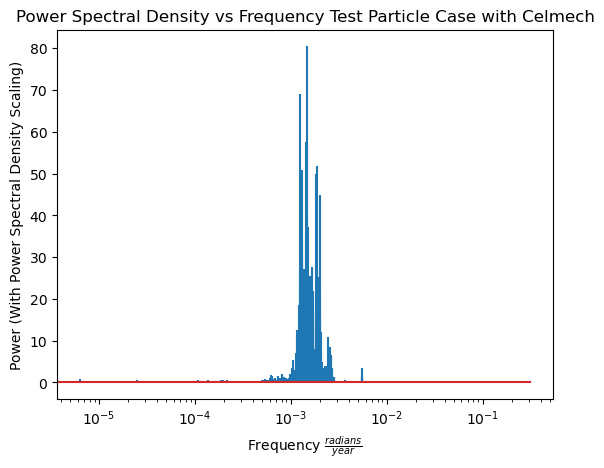

In [96]:
f,pxx = pomega_ft(times, pomega_sat, e_sat)
plt.stem(f*2*np.pi,pxx,markerfmt = "none",label = 'Frequencies found through simulation')
plt.xscale('log')
plt.ylabel('Power (With Power Spectral Density Scaling)')
plt.xlabel(r"Frequency $\frac{radians}{year}$")
plt.title(r'Power Spectral Density vs Frequency Test Particle Case with Celmech')
plt.show()

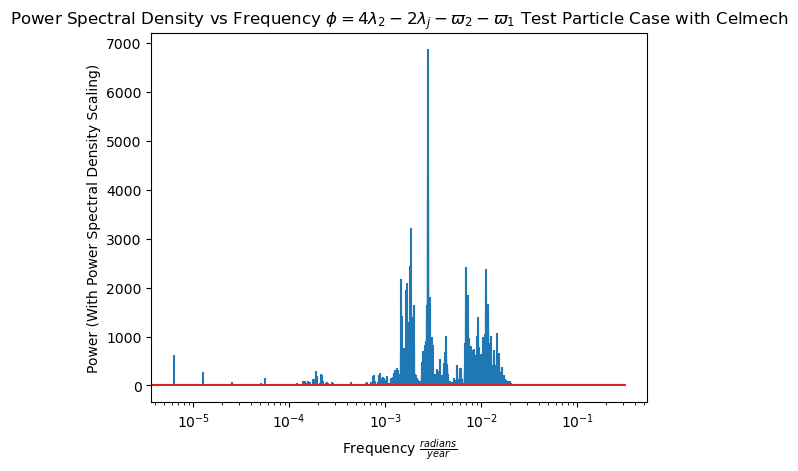

In [97]:
phi_2_mixed = 4*lam_sat - 2*lam_jup - pomega_sat - long_peri_j_test_n_body

phi_3_mixed_s = 6*lam_sat - 3*lam_jup - 2*pomega_sat - pomega_j
phi_3_mixed_j = 6*lam_sat - 3*lam_jup - pomega_sat - 2*pomega_j

f,pxx = ft(times, np.cos(phi_2_mixed))
plt.stem(f*2*np.pi,pxx,markerfmt = "none",label = 'Frequencies found through simulation')
plt.xscale('log')
plt.ylabel('Power (With Power Spectral Density Scaling)')
plt.xlabel(r"Frequency $\frac{radians}{year}$")
plt.title(r'Power Spectral Density vs Frequency $\phi = 4\lambda_2 -2\lambda_j - \varpi_2 - \varpi_1$ Test Particle Case with Celmech')
plt.show()

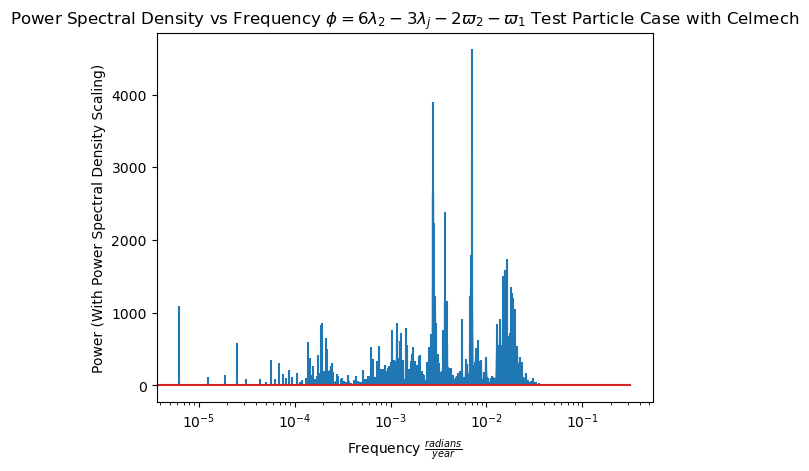

In [98]:
f,pxx = ft(times, np.cos(phi_3_mixed_s))
plt.stem(f*2*np.pi,pxx,markerfmt = "none",label = 'Frequencies found through simulation')
plt.xscale('log')
plt.ylabel('Power (With Power Spectral Density Scaling)')
plt.xlabel(r"Frequency $\frac{radians}{year}$")
plt.title(r'Power Spectral Density vs Frequency $\phi = 6\lambda_2 -3\lambda_j - 2\varpi_2 - \varpi_1$ Test Particle Case with Celmech')
plt.show()

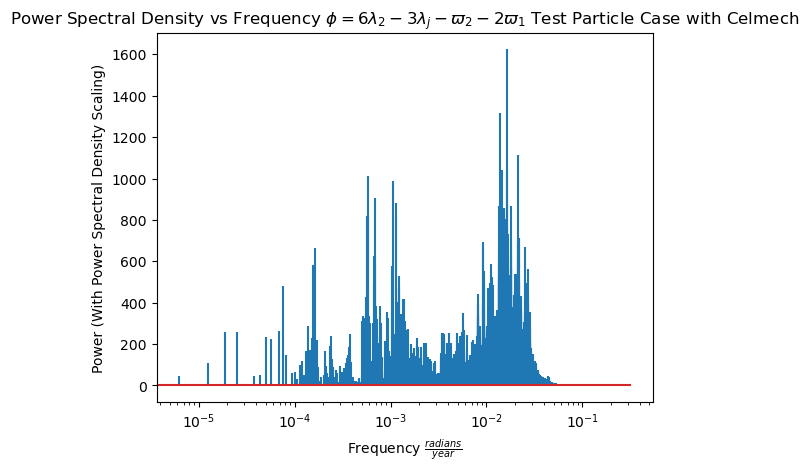

In [105]:
f,pxx = ft(times, np.cos(phi_3_mixed_j))
plt.stem(f*2*np.pi,pxx,markerfmt = "none",label = 'Frequencies found through simulation')
plt.xscale('log')
plt.ylabel('Power (With Power Spectral Density Scaling)')
plt.xlabel(r"Frequency $\frac{radians}{year}$")
plt.title(r'Power Spectral Density vs Frequency $\phi = 6\lambda_2 -3\lambda_j - \varpi_2 - 2\varpi_1$ Test Particle Case with Celmech')
plt.show()

In [106]:
#higher jup eccentricity

sim = rebound.Simulation()
sim.add(m=1, hash = "Sun")
sim.add(m=m_jup,a=5.6,e=0.02,inc = 0,Omega = 0,pomega=np.radians(13.983865),hash="Jupiter")
sim.add(m=1e-10,a=8.87,e=0.04,inc = 0, Omega = 0,pomega=np.radians(88.719425),hash="Saturn")

pvars = Poincare.from_Simulation(sim)

pham = PoincareHamiltonian(pvars)
pham.add_MMR_terms(2,1,indexIn = 1, indexOut = 2, max_order = 2)
pham.add_cosine_term([6,-3,-1,-2,0,0],indexIn = 1, indexOut = 2)
pham.add_secular_terms(indexIn = 1, indexOut = 2, max_order = 2)

times, pomega_sat, pomega_j, e_sat, a_sat, a_jup, lam_sat,lam_jup = hk_integrate(pham, 1e6, 1e5)

['Lambda1', 'Lambda2', 'eta1', 'eta2', 'kappa1', 'kappa2', 'lambda1', 'lambda2']
*** Differentiating  ***
-8.880166634742278e-05
*** Starting Simulation ***


100%|████████████████████████████████████████████████████████████████████████| 100000/100000 [00:07<00:00, 13243.20it/s]

-8.880166634743146e-05
Energy Percent Change: 9.782665420998855e-12 %
*** Simulation Complete ***
Time elapsed  = 7.553378382999654 seconds


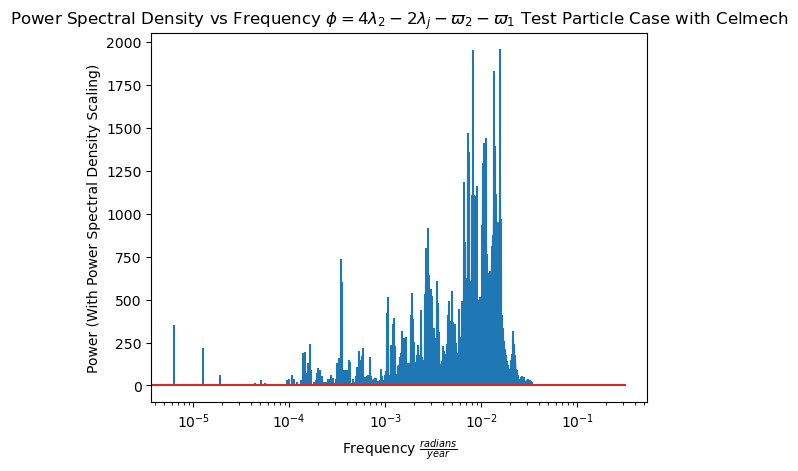

In [107]:
phi_2_mixed = 4*lam_sat - 2*lam_jup - pomega_sat - long_peri_j_test_n_body

phi_3_mixed_s = 6*lam_sat - 3*lam_jup - 2*pomega_sat - pomega_j
phi_3_mixed_j = 6*lam_sat - 3*lam_jup - pomega_sat - 2*pomega_j

f,pxx = ft(times, np.cos(phi_2_mixed))
plt.stem(f*2*np.pi,pxx,markerfmt = "none",label = 'Frequencies found through simulation')
plt.xscale('log')
plt.ylabel('Power (With Power Spectral Density Scaling)')
plt.xlabel(r"Frequency $\frac{radians}{year}$")
plt.title(r'Power Spectral Density vs Frequency $\phi = 4\lambda_2 -2\lambda_j - \varpi_2 - \varpi_1$ Test Particle Case with Celmech')
plt.show()

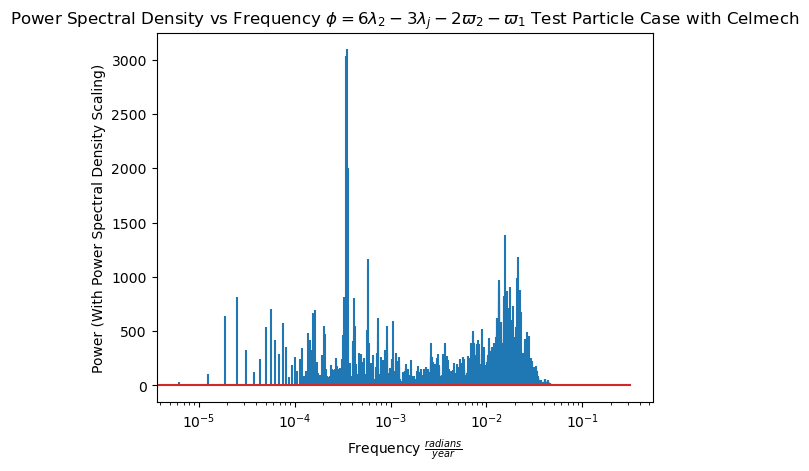

In [108]:
f,pxx = ft(times, np.cos(phi_3_mixed_s))
plt.stem(f*2*np.pi,pxx,markerfmt = "none",label = 'Frequencies found through simulation')
plt.xscale('log')
plt.ylabel('Power (With Power Spectral Density Scaling)')
plt.xlabel(r"Frequency $\frac{radians}{year}$")
plt.title(r'Power Spectral Density vs Frequency $\phi = 6\lambda_2 -3\lambda_j - 2\varpi_2 - \varpi_1$ Test Particle Case with Celmech')
plt.show()

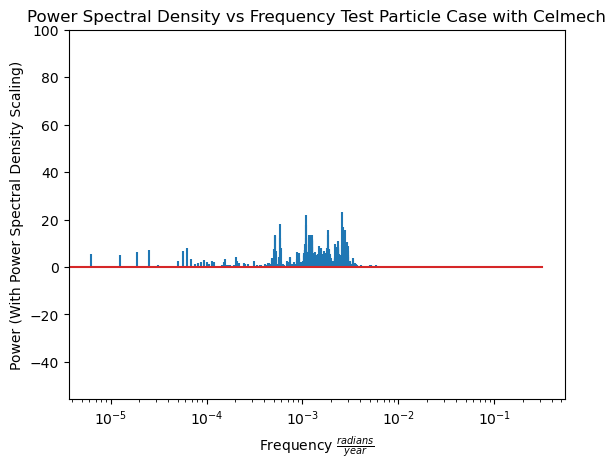

In [111]:
f,pxx = pomega_ft(times, pomega_sat, e_sat)
plt.stem(f*2*np.pi,pxx,markerfmt = "none",label = 'Frequencies found through simulation')
plt.xscale('log')
plt.ylabel('Power (With Power Spectral Density Scaling)')
plt.xlabel(r"Frequency $\frac{radians}{year}$")
plt.title(r'Power Spectral Density vs Frequency Test Particle Case with Celmech')
plt.ylim(top=100)
plt.show()

### looking only at the 3rd order phi = 6\lambda_2 - 3\lambda_1 - \varpi_1 - 2\varpi_2

In [49]:
#higher jup eccentricity

sim = rebound.Simulation()
sim.add(m=1, hash = "Sun")
sim.add(m=m_jup,a=5.6,e=0.02,inc = 0,Omega = 0,pomega=np.radians(13.983865),hash="Jupiter")
sim.add(m=1e-10,a=8.87,e=0.04,inc = 0, Omega = 0,pomega=np.radians(88.719425),hash="Saturn")

pvars = Poincare.from_Simulation(sim)

pham = PoincareHamiltonian(pvars)
pham.add_MMR_terms(2,1,indexIn = 1, indexOut = 2, max_order = 2)
pham.add_cosine_term([6,-3,-2,-1,0,0],indexIn = 1, indexOut = 2)
pham.add_secular_terms(indexIn = 1, indexOut = 2, max_order = 2)

times, pomega_sat, pomega_j, e_sat, a_sat, a_jup, lam_sat,lam_jup = hk_integrate(pham, 1e6, 1e5)

['Lambda1', 'Lambda2', 'eta1', 'eta2', 'kappa1', 'kappa2', 'lambda1', 'lambda2']
*** Differentiating  ***
-8.880166634742855e-05
*** Starting Simulation ***


100%|████████████████████████████████████████████████████████████████████████| 100000/100000 [00:07<00:00, 13316.00it/s]

-8.88016663474301e-05
Energy Percent Change: 1.739818811222772e-12 %
*** Simulation Complete ***
Time elapsed  = 7.5117482979999295 seconds


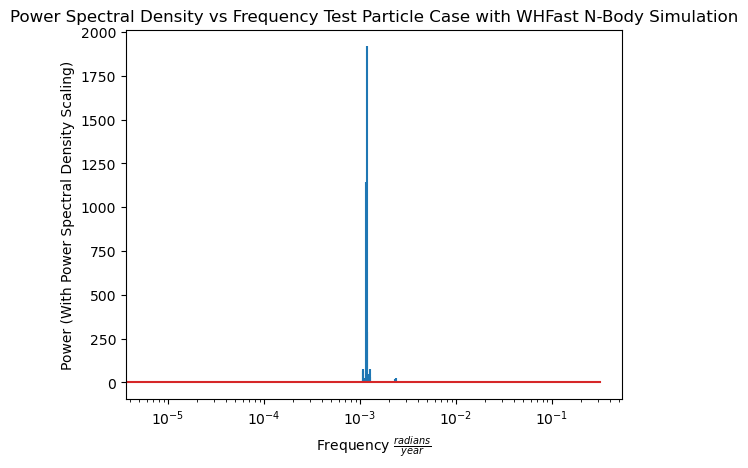

In [50]:
f,pxx = pomega_ft(times, pomega_sat, e_sat)
plt.stem(f*2*np.pi,pxx,markerfmt = "none",label = 'Frequencies found through simulation')
plt.xscale('log')
plt.ylabel('Power (With Power Spectral Density Scaling)')
plt.xlabel(r"Frequency $\frac{radians}{year}$")
plt.title(r'Power Spectral Density vs Frequency Test Particle Case with WHFast N-Body Simulation')
plt.show()

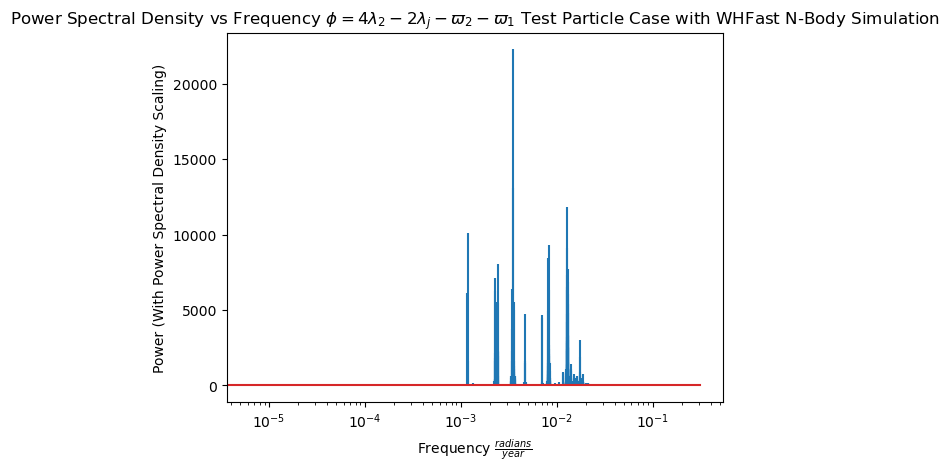

In [51]:
phi_2_mixed = 4*lam_sat - 2*lam_jup - pomega_sat - long_peri_j_test_n_body

phi_3_mixed_s = 6*lam_sat - 3*lam_jup - 2*pomega_sat - pomega_j
phi_3_mixed_j = 6*lam_sat - 3*lam_jup - pomega_sat - 2*pomega_j


f,pxx = ft(times, np.cos(phi_2_mixed))
plt.stem(f*2*np.pi,pxx,markerfmt = "none",label = 'Frequencies found through simulation')
plt.xscale('log')
plt.ylabel('Power (With Power Spectral Density Scaling)')
plt.xlabel(r"Frequency $\frac{radians}{year}$")
plt.title(r'Power Spectral Density vs Frequency $\phi = 4\lambda_2 -2\lambda_j - \varpi_2 - \varpi_1$ Test Particle Case with WHFast N-Body Simulation')
plt.show()

### both of the mixed  3rd Order Terms

### all 3rd order terms

In [68]:
#higher jup eccentricity

sim = rebound.Simulation()
sim.add(m=1, hash = "Sun")
sim.add(m=m_jup,a=5.6,e=0.02,inc = 0,Omega = 0,pomega=np.radians(13.983865),hash="Jupiter")
sim.add(m=1e-10,a=8.87,e=0.04,inc = 0, Omega = 0,pomega=np.radians(88.719425),hash="Saturn")

pvars = Poincare.from_Simulation(sim)

pham = PoincareHamiltonian(pvars)
pham.add_MMR_terms(2,1,indexIn = 1, indexOut = 2, max_order = 3)
pham.add_secular_terms(indexIn = 1, indexOut = 2, max_order = 2)

times, pomega_sat, pomega_j, e_sat, a_sat, a_jup, lam_sat,lam_jup = hk_integrate(pham, 1e6, 1e5)

['Lambda1', 'Lambda2', 'eta1', 'eta2', 'kappa1', 'kappa2', 'lambda1', 'lambda2']
*** Differentiating  ***
-8.880166634741921e-05
*** Starting Simulation ***


100%|█████████████████████████████████████████████████████████████████████████| 100000/100000 [00:13<00:00, 7168.81it/s]

-8.88016663474148e-05
Energy Percent Change: 4.960009768837372e-12 %
*** Simulation Complete ***
Time elapsed  = 13.95184561699989 seconds


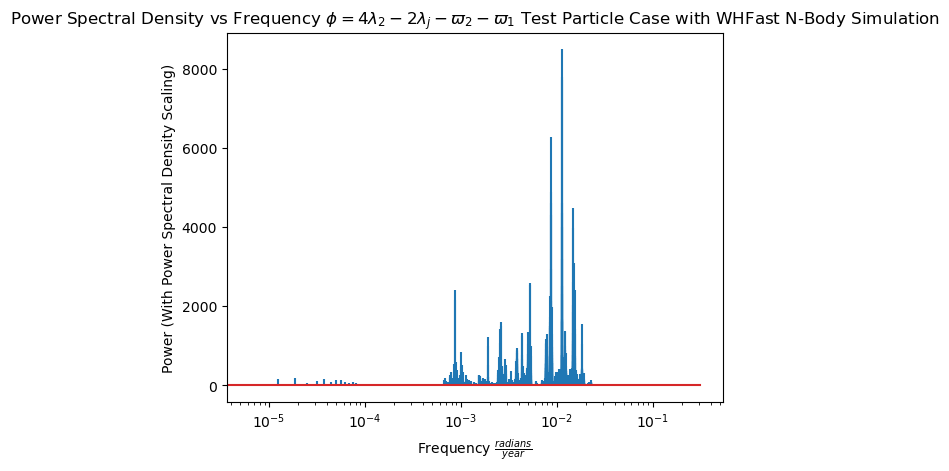

In [71]:
phi_2_mixed = 4*lam_sat - 2*lam_jup - pomega_sat - long_peri_j_test_n_body

phi_3_mixed_s = 6*lam_sat - 3*lam_jup - 2*pomega_sat - pomega_j
phi_3_mixed_j = 6*lam_sat - 3*lam_jup - pomega_sat - 2*pomega_j

f,pxx = ft(times, np.cos(phi_2_mixed))
plt.stem(f*2*np.pi,pxx,markerfmt = "none",label = 'Frequencies found through simulation')
plt.xscale('log')
plt.ylabel('Power (With Power Spectral Density Scaling)')
plt.xlabel(r"Frequency $\frac{radians}{year}$")
plt.title(r'Power Spectral Density vs Frequency $\phi = 4\lambda_2 -2\lambda_j - \varpi_2 - \varpi_1$ Test Particle Case with WHFast N-Body Simulation')
plt.show()

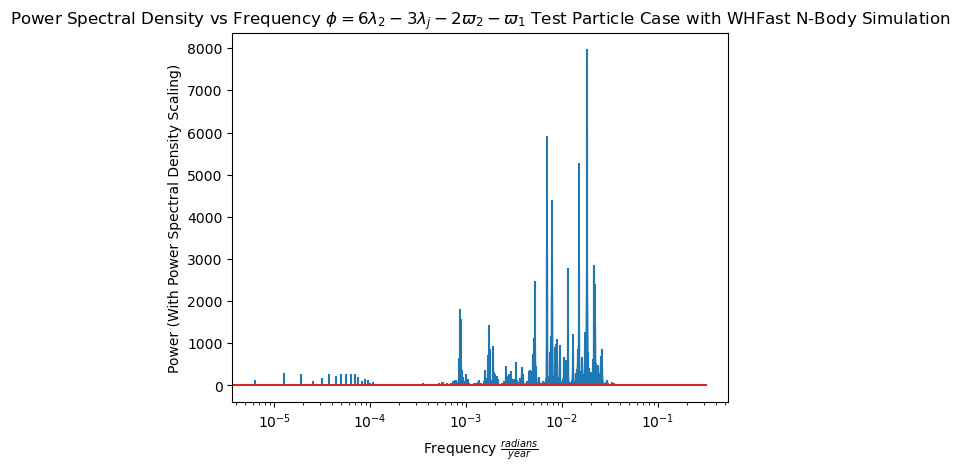

In [72]:
f,pxx = ft(times, np.cos(phi_3_mixed_s))
plt.stem(f*2*np.pi,pxx,markerfmt = "none",label = 'Frequencies found through simulation')
plt.xscale('log')
plt.ylabel('Power (With Power Spectral Density Scaling)')
plt.xlabel(r"Frequency $\frac{radians}{year}$")
plt.title(r'Power Spectral Density vs Frequency $\phi = 6\lambda_2 -3\lambda_j - 2\varpi_2 - \varpi_1$ Test Particle Case with WHFast N-Body Simulation')
plt.show()

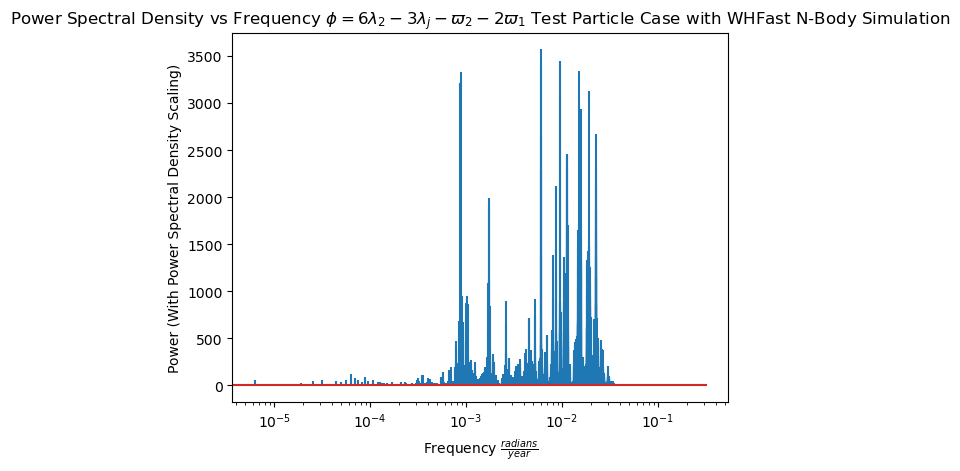

In [73]:
f,pxx = ft(times, np.cos(phi_3_mixed_j))
plt.stem(f*2*np.pi,pxx,markerfmt = "none",label = 'Frequencies found through simulation')
plt.xscale('log')
plt.ylabel('Power (With Power Spectral Density Scaling)')
plt.xlabel(r"Frequency $\frac{radians}{year}$")
plt.title(r'Power Spectral Density vs Frequency $\phi = 6\lambda_2 -3\lambda_j - \varpi_2 - 2\varpi_1$ Test Particle Case with WHFast N-Body Simulation')
plt.show()

In [74]:
#low jup eccentricity

sim = rebound.Simulation()
sim.add(m=1, hash = "Sun")
sim.add(m=m_jup,a=5.6,e=0.015,inc = 0,Omega = 0,pomega=np.radians(13.983865),hash="Jupiter")
sim.add(m=1e-10,a=8.87,e=0.04,inc = 0, Omega = 0,pomega=np.radians(88.719425),hash="Saturn")

pvars = Poincare.from_Simulation(sim)

pham = PoincareHamiltonian(pvars)
pham.add_MMR_terms(2,1,indexIn = 1, indexOut = 2, max_order = 3)
pham.add_secular_terms(indexIn = 1, indexOut = 2, max_order = 2)

times, pomega_sat, pomega_j, e_sat, a_sat, a_jup, lam_sat,lam_jup = hk_integrate(pham, 1e6, 1e5)

['Lambda1', 'Lambda2', 'eta1', 'eta2', 'kappa1', 'kappa2', 'lambda1', 'lambda2']
*** Differentiating  ***
-8.88016663473214e-05
*** Starting Simulation ***


100%|█████████████████████████████████████████████████████████████████████████| 100000/100000 [00:13<00:00, 7252.00it/s]

-8.880166634733382e-05
Energy Percent Change: 1.3979596763877035e-11 %
*** Simulation Complete ***
Time elapsed  = 13.79171461199985 seconds


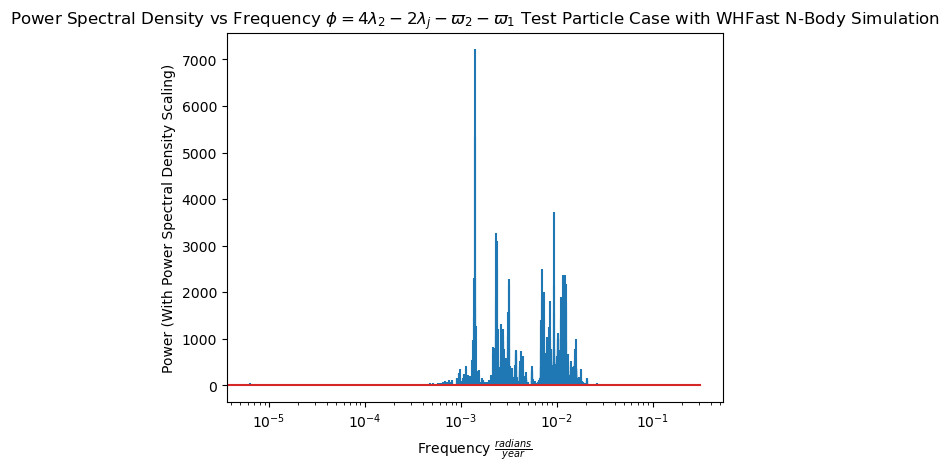

In [75]:
phi_2_mixed = 4*lam_sat - 2*lam_jup - pomega_sat - long_peri_j_test_n_body

phi_3_mixed_s = 6*lam_sat - 3*lam_jup - 2*pomega_sat - pomega_j
phi_3_mixed_j = 6*lam_sat - 3*lam_jup - pomega_sat - 2*pomega_j

f,pxx = ft(times, np.cos(phi_2_mixed))
plt.stem(f*2*np.pi,pxx,markerfmt = "none",label = 'Frequencies found through simulation')
plt.xscale('log')
plt.ylabel('Power (With Power Spectral Density Scaling)')
plt.xlabel(r"Frequency $\frac{radians}{year}$")
plt.title(r'Power Spectral Density vs Frequency $\phi = 4\lambda_2 -2\lambda_j - \varpi_2 - \varpi_1$ Test Particle Case with WHFast N-Body Simulation')
plt.show()

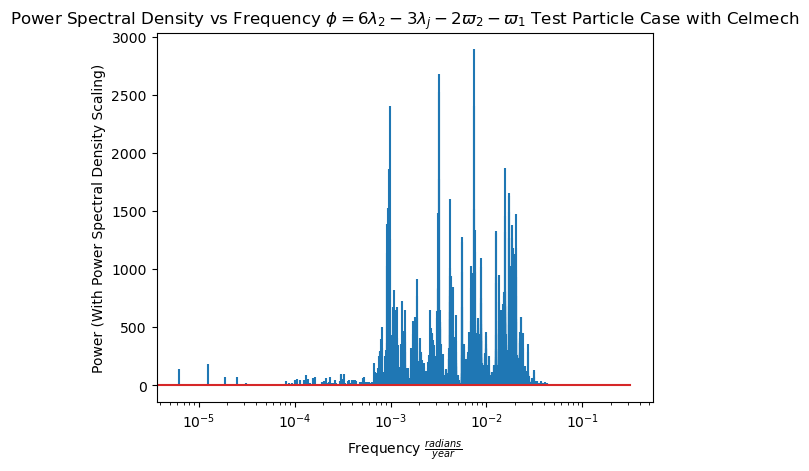

In [76]:
f,pxx = ft(times, np.cos(phi_3_mixed_s))
plt.stem(f*2*np.pi,pxx,markerfmt = "none",label = 'Frequencies found through simulation')
plt.xscale('log')
plt.ylabel('Power (With Power Spectral Density Scaling)')
plt.xlabel(r"Frequency $\frac{radians}{year}$")
plt.title(r'Power Spectral Density vs Frequency $\phi = 6\lambda_2 -3\lambda_j - 2\varpi_2 - \varpi_1$ Test Particle Case with Celmech')
plt.show()